<a href="https://colab.research.google.com/github/SilviaMaharjan/AI-ML_Workshops/blob/main/SilviaMaharjan_2408228_Worksheet2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 - Worksheet 2: Image Classification Using Softmax Regression


## Section 3.1 - Decision Function

In [1]:
import numpy as np

def softmax(z):
    """
    Compute the softmax probabilities for a given input matrix.
    Parameters:
        z (numpy.ndarray): Logits (raw scores) of shape (m, n)
    Returns:
        numpy.ndarray: Softmax probability matrix of shape (m, n)
    """
    # Numerical stabilization: subtract max per row to avoid overflow
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [2]:
# Test Case - Softmax
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)
row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"
print("Softmax function passed the test case!")

Softmax function passed the test case!


In [3]:
def predict_softmax(X, W, b):
    """
    Predict the class labels for a set of samples using the trained softmax model.
    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d)
        W (numpy.ndarray): Weight matrix of shape (d, c)
        b (numpy.ndarray): Bias vector of shape (c,)
    Returns:
        numpy.ndarray: Predicted class labels of shape (n,)
    """
    z = np.dot(X, W) + b          # Compute logits: shape (n, c)
    probs = softmax(z)             # Compute softmax probabilities
    predicted_classes = np.argmax(probs, axis=1)  # Pick class with highest probability
    return predicted_classes

In [4]:
# Test Case - Prediction Function
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])
y_pred_test = predict_softmax(X_test, W_test, b_test)
assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"
print("Predicted class labels:", y_pred_test)

Predicted class labels: [1 1 0]


## Section 3.2 - Loss and Cost Functions

In [5]:
def loss_softmax(y_pred, y):
    """
    Compute the cross-entropy loss.
    Parameters:
        y_pred (numpy.ndarray): Predicted probabilities, shape (n, c) or (c,)
        y (numpy.ndarray): True one-hot labels, same shape as y_pred
    Returns:
        float: Cross-entropy loss
    """
    # Clip predictions to avoid log(0)
    y_pred_clipped = np.clip(y_pred, 1e-15, 1 - 1e-15)
    n = y.shape[0]
    loss = -np.sum(y * np.log(y_pred_clipped)) / n
    return loss

In [6]:
# Test Case - Loss Function
y_true_correct = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
y_pred_correct = np.array([[0.9, 0.05, 0.05],
                            [0.1, 0.85, 0.05],
                            [0.05, 0.1, 0.85]])
y_pred_incorrect = np.array([[0.05, 0.05, 0.9],
                              [0.1, 0.05, 0.85],
                              [0.85, 0.1, 0.05]])

loss_correct = loss_softmax(y_pred_correct, y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

assert loss_correct < loss_incorrect, f"Test failed: Expected loss_correct < loss_incorrect, but got {loss_correct:.4f} >= {loss_incorrect:.4f}"
print(f"Cross-Entropy Loss (Correct Predictions): {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")

Cross-Entropy Loss (Correct Predictions): 0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957


In [7]:
def cost_softmax(X, y, W, b):
    """
    Compute the average softmax regression cost (cross-entropy loss) over all samples.
    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d)
        y (numpy.ndarray): True labels one-hot encoded of shape (n, c)
        W (numpy.ndarray): Weight matrix of shape (d, c)
        b (numpy.ndarray): Bias vector of shape (c,)
    Returns:
        float: Average cross-entropy cost
    """
    n = X.shape[0]
    z = np.dot(X, W) + b            # Logits: (n, c)
    y_pred = softmax(z)             # Probabilities: (n, c)
    y_pred_clipped = np.clip(y_pred, 1e-15, 1 - 1e-15)
    total_loss = -np.sum(y * np.log(y_pred_clipped))
    return total_loss / n

In [8]:
# Test Case - Cost Function
X_correct = np.array([[1.0, 0.0], [0.0, 1.0]])
y_correct = np.array([[1, 0], [0, 1]])
W_correct = np.array([[5.0, -2.0], [-3.0, 5.0]])
b_correct = np.array([0.1, 0.1])

X_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]])
y_incorrect = np.array([[1, 0], [0, 1]])
W_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]])
b_incorrect = np.array([0.5, 0.6])

cost_correct = cost_softmax(X_correct, y_correct, W_correct, b_correct)
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

assert cost_incorrect > cost_correct, f"Test failed: Incorrect cost {cost_incorrect} is not greater than correct cost {cost_correct}"
print("Cost for correct prediction:", cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")

Cost for correct prediction: 0.0006234364133349324
Cost for incorrect prediction: 0.29930861359446115
Test passed!


## Section 3.3 - Gradient Descent

In [9]:
def compute_gradient_softmax(X, y, W, b):
    """
    Compute the gradients of the cost function w.r.t. weights and biases.
    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d)
        y (numpy.ndarray): True labels one-hot encoded of shape (n, c)
        W (numpy.ndarray): Weight matrix of shape (d, c)
        b (numpy.ndarray): Bias vector of shape (c,)
    Returns:
        tuple: (grad_W of shape (d, c), grad_b of shape (c,))
    """
    n = X.shape[0]
    z = np.dot(X, W) + b            # Logits: (n, c)
    y_pred = softmax(z)             # Probabilities: (n, c)
    error = y_pred - y              # Difference: (n, c)
    grad_W = np.dot(X.T, error) / n # Gradient w.r.t. W: (d, c)
    grad_b = np.sum(error, axis=0) / n  # Gradient w.r.t. b: (c,)
    return grad_W, grad_b

In [10]:
# Test Case - Compute Gradient
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

z_test = np.dot(X_test, W_test) + b_test
y_pred_test = softmax(z_test)
grad_W_manual = np.dot(X_test.T, (y_pred_test - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test, axis=0) / X_test.shape[0]

assert np.allclose(grad_W, grad_W_manual), f"Test failed: Gradients w.r.t. W are not equal."
assert np.allclose(grad_b, grad_b_manual), f"Test failed: Gradients w.r.t. b are not equal."
print("Gradient w.r.t. W:", grad_W)
print("Gradient w.r.t. b:", grad_b)
print("Test passed!")

Gradient w.r.t. W: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


In [11]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimize weights and biases.
    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d)
        y (numpy.ndarray): True labels one-hot encoded of shape (n, c)
        W (numpy.ndarray): Initial weight matrix of shape (d, c)
        b (numpy.ndarray): Initial bias vector of shape (c,)
        alpha (float): Learning rate
        n_iter (int): Number of iterations
        show_cost (bool): Whether to print cost at intervals
    Returns:
        tuple: Optimized W, b, and cost_history list
    """
    cost_history = []

    for i in range(n_iter):
        # Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Update parameters
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        # Compute and record cost
        current_cost = cost_softmax(X, y, W, b)
        cost_history.append(current_cost)

        # Optionally print cost every 100 iterations
        if show_cost and i % 100 == 0:
            print(f"Iteration {i}: Cost = {current_cost:.4f}")

    return W, b, cost_history

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Section 3.4 - Load and Prepare MNIST Dataset

### Question 1:
**Is extracting pixel values sufficient for effective feature extraction? Why or why not?**

Extracting raw pixel values is a starting point but is generally **not sufficient** for effective feature extraction on its own. Here's why:

- **High dimensionality**: A 28×28 image yields 784 features. Many of these pixels carry redundant or irrelevant information, which can slow down training and hurt generalisation.
- **Lack of spatial invariance**: Raw pixels are sensitive to small shifts, rotations, or scaling of the digit. A handwritten "3" shifted one pixel to the right produces an entirely different feature vector, even though it's the same digit.
- **No structural information**: Pixel values alone don't encode edges, curves, or stroke patterns — the kinds of structural features that actually distinguish one digit from another.
- **Better alternatives**: Techniques such as HOG (Histogram of Oriented Gradients), PCA for dimensionality reduction, or learned representations from CNNs capture much richer and more discriminative information.

For simple datasets like MNIST, pixel values can work reasonably well because the images are already normalised and centred. However, for more complex real-world datasets, raw pixels alone would be far from sufficient.

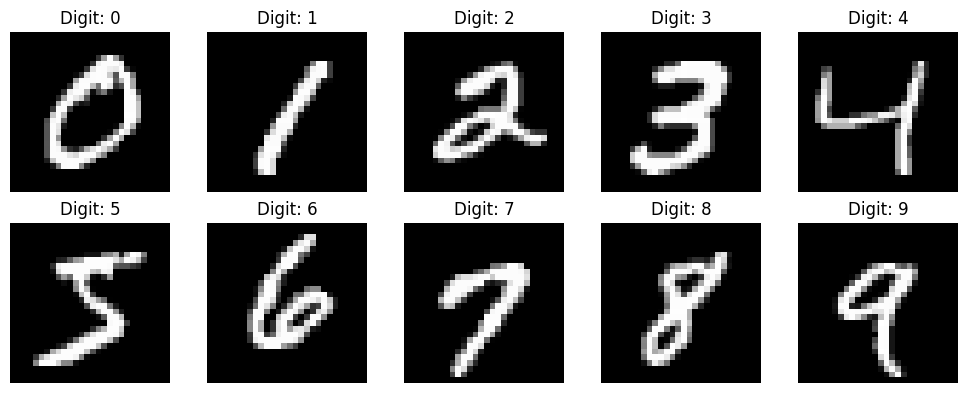

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def plot_sample_images(X, y):
    """
    Plots one sample image for each digit class (0-9).
    """
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y)
    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]
        image = X[index].reshape(28, 28)
        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()


def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    """
    Reads the MNIST CSV file, splits data into train/test sets,
    and plots one image per class.
    """
    df = pd.read_csv('/content/drive/MyDrive/AI and ML/mnist_dataset.csv')
    y = df.iloc[:, 0].values       # First column is the label
    X = df.iloc[:, 1:].values      # Remaining columns are pixel values

    # Normalize pixel values to [0, 1]
    X = X / 255.0

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Plot sample images
    plot_sample_images(X, y)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_and_prepare_mnist('/content/drive/MyDrive/AI and ML/mnist_train.csv')

## Section 3.5 - Training the Model

Move forward: Dimension of Feature Matrix X and label vector y matched.
Iteration 0: Cost = 2.2036
Iteration 100: Cost = 0.6074
Iteration 200: Cost = 0.4896
Iteration 300: Cost = 0.4410
Iteration 400: Cost = 0.4129
Iteration 500: Cost = 0.3940
Iteration 600: Cost = 0.3802
Iteration 700: Cost = 0.3695
Iteration 800: Cost = 0.3608
Iteration 900: Cost = 0.3537


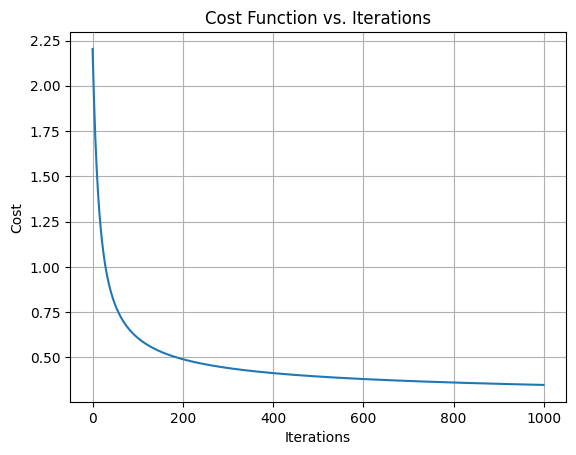

In [17]:
from sklearn.preprocessing import OneHotEncoder

assert len(X_train) == len(y_train), f"Error: X and y have different lengths!"
print("Move forward: Dimension of Feature Matrix X and label vector y matched.")

# One-hot encode labels if not already
if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test  = encoder.transform(y_test.reshape(-1, 1))

d = X_train.shape[1]          # Number of features
c = y_train.shape[1]          # Number of classes

# Initialise weights and biases
W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

# Hyperparameters
alpha  = 0.1
n_iter = 1000

# Train
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter, show_cost=True
)

# Plot cost history
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

## Section 3.6 - Model Evaluation


Confusion Matrix:
[[1127    0    5    2    3   11    9    2   13    3]
 [   0 1276    7   11    1    5    1    4   16    1]
 [   1   16 1030   16   19    4   26   25   31    6]
 [   8    5   33 1052    1   51    9    8   31   21]
 [   1    5    7    1 1094    0   10    4    3   51]
 [  22   14   12   42   12  927   14    7   41   13]
 [   7    2   10    1   11   15 1119    2   10    0]
 [   6   27   24    5   16    2    0 1182    7   30]
 [   9   28   14   35   10   33   11    7  998   15]
 [   8    6   10   18   46    9    0   39   10 1048]]
Precision: 0.90
Recall:    0.90
F1-Score:  0.90


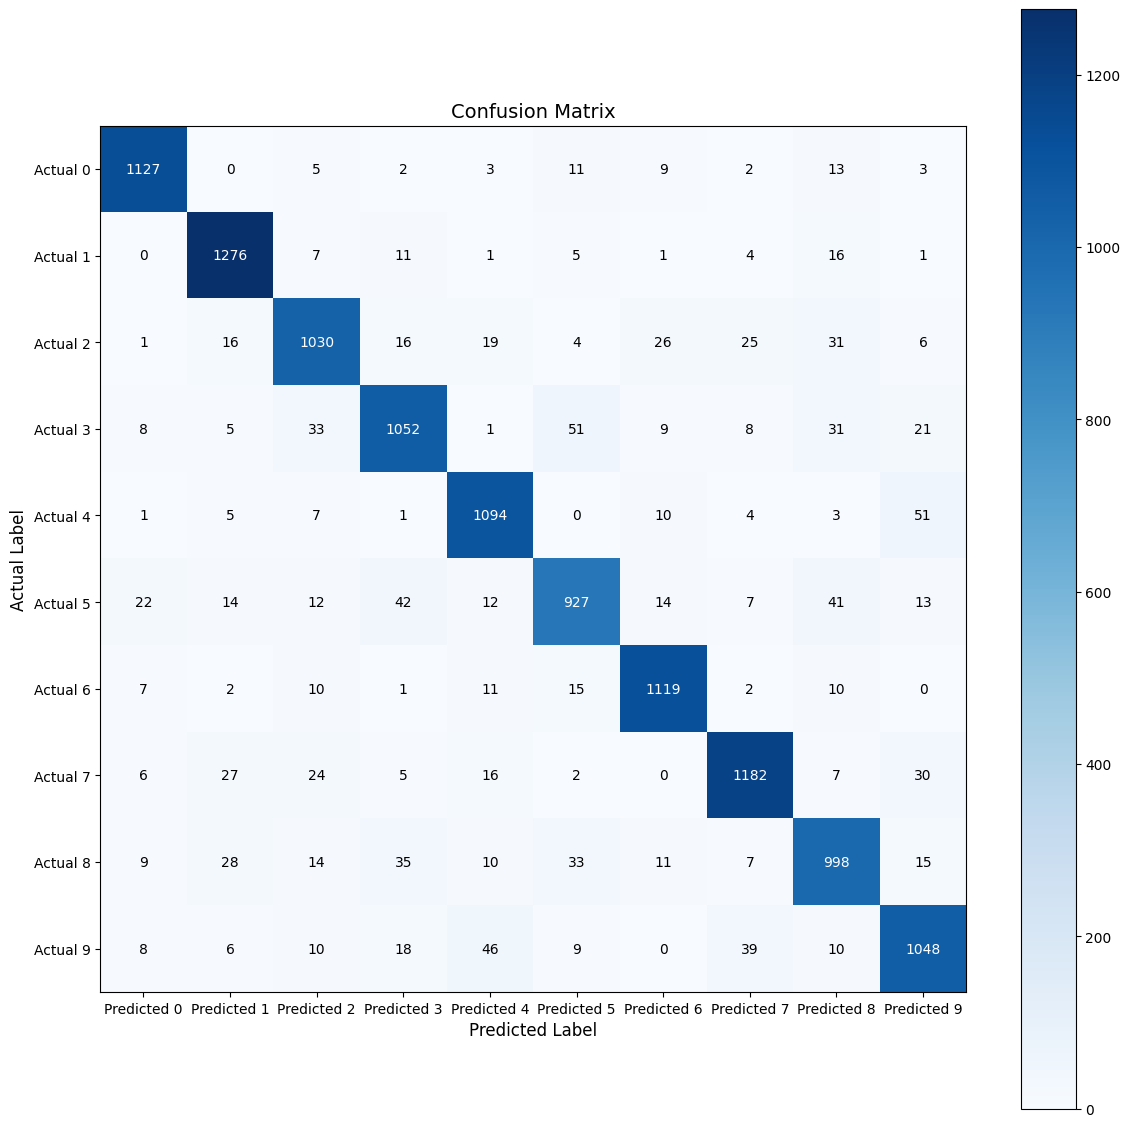

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification performance using confusion matrix,
    precision, recall, and F1-score.
    """
    cm        = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall    = recall_score(y_true, y_pred, average='weighted')
    f1        = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1

y_pred_test   = predict_softmax(X_test, W_opt, b_opt)
y_test_labels = np.argmax(y_test, axis=1)

cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-Score:  {f1:.2f}")

# Visualise Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues')
num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}'    for i in range(num_classes)])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > np.max(cm) / 2 else 'black')
ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.colorbar(cax)
plt.show()

## Section 4 - Linear Separability and Logistic Regression

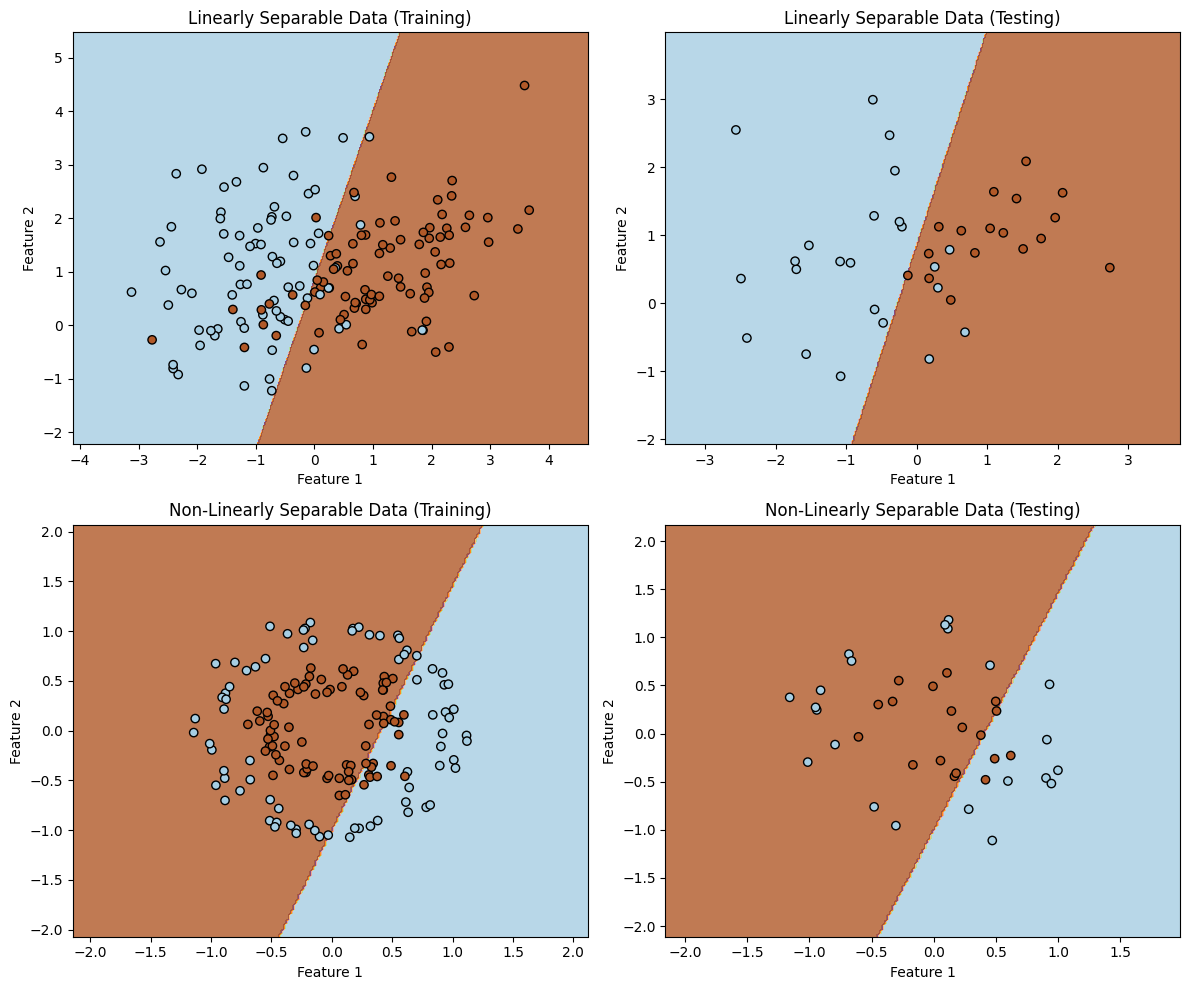

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

# Linearly separable dataset
X_linear_separable, y_linear_separable = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)
logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

# Non-linearly separable dataset (circles)
X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200, noise=0.1, factor=0.5, random_state=42
)
X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)
logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)


def plot_decision_boundary(ax, model, X, y, title):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_decision_boundary(axes[0, 0], logistic_model_linear_separable,
                       X_train_linear, y_train_linear,
                       'Linearly Separable Data (Training)')
plot_decision_boundary(axes[0, 1], logistic_model_linear_separable,
                       X_test_linear, y_test_linear,
                       'Linearly Separable Data (Testing)')
plot_decision_boundary(axes[1, 0], logistic_model_non_linear_separable,
                       X_train_non_linear, y_train_non_linear,
                       'Non-Linearly Separable Data (Training)')
plot_decision_boundary(axes[1, 1], logistic_model_non_linear_separable,
                       X_test_non_linear, y_test_non_linear,
                       'Non-Linearly Separable Data (Testing)')

plt.tight_layout()
plt.savefig('decision_boundaries.png')
plt.show()

### Question 2: Interpretation of the Decision Boundary Plots

1. Linearly Separable Data (top row):
The model draws a clean straight boundary that separates both classes well, and it holds up on the test set too — so no overfitting.
2. Non-Linearly Separable Data (bottom row):
The data forms concentric circles which a straight line can't separate. The model misclassifies many points on both training and test sets, showing that logistic regression just isn't suited for non-linear problems.

### Question 3: Challenges Faced

Several challenges may be encountered when implementing and running this code:

1. Numerical instability: Had to subtract the row max before exp(z) to stop overflow.
2. Log(0) errors: Clipped predictions to 1e-15 so the loss doesn't blow up.
3. Shape mismatches: Matrix dimensions needed careful tracking — easy to get a transpose wrong and break everything silently.
4. One-hot encoding: Easy to forget, causes wrong loss values if missed.
5. Slow training: Full-batch gradient descent on MNIST is slow — learning rate needs to be tuned carefully or it either diverges or crawls.